<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part I · Foundations &nbsp;|&nbsp; Chapter 3</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Data Science Lifecycle <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:710px;line-height:1.6">One complete mini-project, predicting ice-cream sales from temperature, walked through all six stages of the lifecycle, with working code and a chart at every step.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 The project: *"How many ice creams will we sell tomorrow?"*
A small shop wants to staff and stock correctly. We'll go end-to-end through the lifecycle:

| Stage | What we do | Output |
|------|-----------|--------|
| 1 · Frame | Turn the business need into a data question + metric | a clear goal |
| 2 · Collect | Gather the raw data | a raw dataset |
| 3 · Clean | Fix duplicates, missing values, outliers | a tidy dataset |
| 4 · Explore | Look for the pattern (EDA) | insight + correlation |
| 5 · Model | Learn the temperature→sales relationship | a trained model |
| 6 · Evaluate &amp; Deploy | Test it, then predict &amp; decide | a usable forecast |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"
GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax, title, subtitle=None):
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=INK_SOFT, va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">STAGE 1 · FRAME THE QUESTION</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 From a business need to a data question</div>
<div style="color:#4a5578;margin-top:6px">Input: a vague goal ("don't run out of ice cream"). Output: a precise, measurable question + a success metric.</div>
</div>

In [2]:
QUESTION = "Can we predict daily ice-cream sales from the day's temperature?"
TARGET   = "sales"        # what we want to predict (the label)
FEATURE  = "temperature"  # what we predict it from
METRIC   = "RMSE (typical error in number of ice creams) — lower is better"

print("QUESTION :", QUESTION)
print("PREDICT  :", TARGET, "   FROM:", FEATURE)
print("SUCCESS  :", METRIC)

QUESTION : Can we predict daily ice-cream sales from the day's temperature?
PREDICT  : sales    FROM: temperature
SUCCESS  : RMSE (typical error in number of ice creams) — lower is better


A good question is **specific and measurable**. "Sell more" is a wish; *"predict daily sales from temperature, measured by RMSE"* is something data can actually answer.

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">STAGE 2 · COLLECT THE DATA</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🗄️ Gather the raw data</div>
<div style="color:#4a5578;margin-top:6px">Input: the question. Output: a raw dataset, usually messy, like the real world.</div>
</div>

In [3]:
# 14 days of records (temperature in °C, ice creams sold). Real data is rarely clean:
raw = pd.DataFrame({
    "temperature": [18, 20, 21, 23, 25, 26, 28, 30, 31, 33, 25, 27, 22, 24],
    "sales":       [22, 28, 30, 35, 40, 44, 52, 60,  5, 70, 40, None, 26, 34],
})
print(f"Collected {len(raw)} rows.")
raw

Collected 14 rows.


,temperature,sales
0,18,22.0
1,20,28.0
2,21,30.0
3,23,35.0
4,25,40.0
5,26,44.0
6,28,52.0
7,30,60.0
8,31,5.0
9,33,70.0


Notice three real-world problems hiding in here: a **duplicate** day, a **missing** sales value (`NaN`), and an **outlier** (a hot day with only 5 sales, almost certainly a typo).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">STAGE 3 · CLEAN &amp; PREPARE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧹 Turn messy data into tidy data</div>
<div style="color:#4a5578;margin-top:6px">Input: raw messy data. Output: a clean, trustworthy dataset. (Often ~80% of a project's time!)</div>
</div>

In [4]:
data = raw.copy()
before = len(data)

# (a) DUPLICATES — drop exact repeat rows
data = data.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(data)} duplicate row(s).")

# (b) MISSING VALUES — fill the gap with the average sales
fill_value = round(data["sales"].mean())
n_missing = int(data["sales"].isna().sum())
data["sales"] = data["sales"].fillna(fill_value)
print(f"Filled {n_missing} missing sales value(s) with the mean ({fill_value}).")

# (c) OUTLIERS — a hot day with almost no sales is a data-entry error; drop it
outliers = data[(data["temperature"] > 28) & (data["sales"] < 15)]
data = data.drop(outliers.index).reset_index(drop=True)
print(f"Removed {len(outliers)} outlier row(s).")
print(f"\nClean dataset: {len(data)} rows ready for analysis.")

Removed 1 duplicate row(s).
Filled 1 missing sales value(s) with the mean (37).
Removed 1 outlier row(s).

Clean dataset: 12 rows ready for analysis.


Each fix matters: duplicates **double-count**, missing values **break math**, and outliers **distort the pattern**. Garbage in → garbage out.

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">STAGE 4 · EXPLORE &amp; ANALYZE (EDA)</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔍 Find the pattern</div>
<div style="color:#4a5578;margin-top:6px">Input: clean data. Output: insight, what relates to what, and how strongly.</div>
</div>

In [5]:
print(data[["temperature","sales"]].describe().round(1))

corr = data["temperature"].corr(data["sales"])
print(f"\nCorrelation(temperature, sales) = {corr:.2f}  -> strong, positive")

       temperature  sales
count         12.0   12.0
mean          24.8   39.8
std            4.3   14.4
min           18.0   22.0
25%           21.8   29.5
50%           24.5   36.0
75%           27.2   46.0
max           33.0   70.0

Correlation(temperature, sales) = 0.96  -> strong, positive


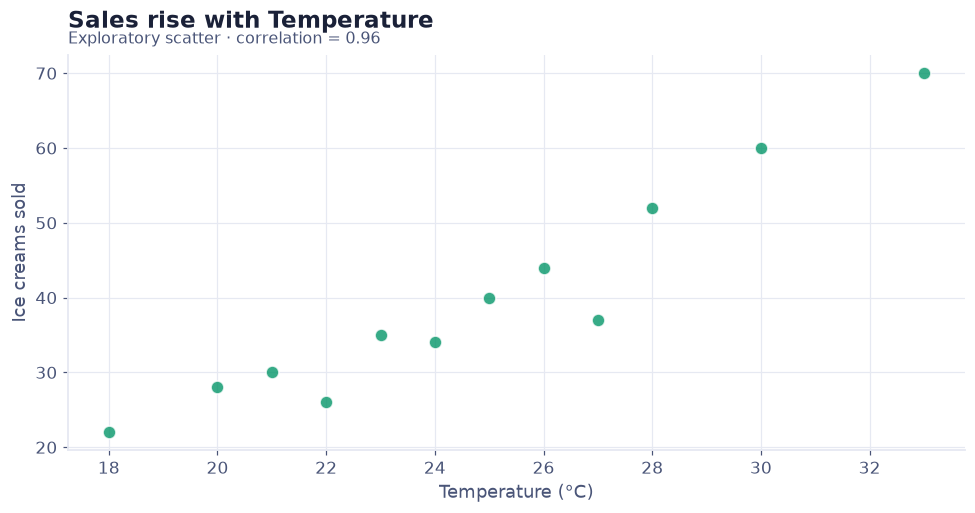

In [6]:
fig, ax = plt.subplots(figsize=(9,4.8))
ax.scatter(data["temperature"], data["sales"], color=GREEN, s=70, alpha=0.8, edgecolor="white", linewidth=1)
titlecard(ax, "Sales rise with Temperature", f"Exploratory scatter · correlation = {corr:.2f}")
ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("Ice creams sold")
plt.tight_layout(); plt.show()

EDA confirms a clear, strong upward relationship, warm days sell more. That pattern is what the model will learn.

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">STAGE 5 · MODEL</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🤖 Learn the relationship</div>
<div style="color:#4a5578;margin-top:6px">Input: prepared features + target, split into train/test. Output: a trained model. We train ONLY on the training half (no peeking at the test set).</div>
</div>

In [7]:
# Split into TRAIN (learn from) and TEST (judge on) — never evaluate on data you trained on
idx = rng.permutation(len(data))
test_idx  = idx[:4]
train_idx = idx[4:]
train, test = data.iloc[train_idx], data.iloc[test_idx]
print(f"Train on {len(train)} days, test on {len(test)} held-out days.")

# "Train" the model = fit the best straight line on the TRAIN data only
slope, intercept = np.polyfit(train["temperature"], train["sales"], 1)
print(f"Learned model:  sales = {intercept:.1f} + {slope:.1f} * temperature")

Train on 8 days, test on 4 held-out days.
Learned model:  sales = -34.3 + 3.0 * temperature


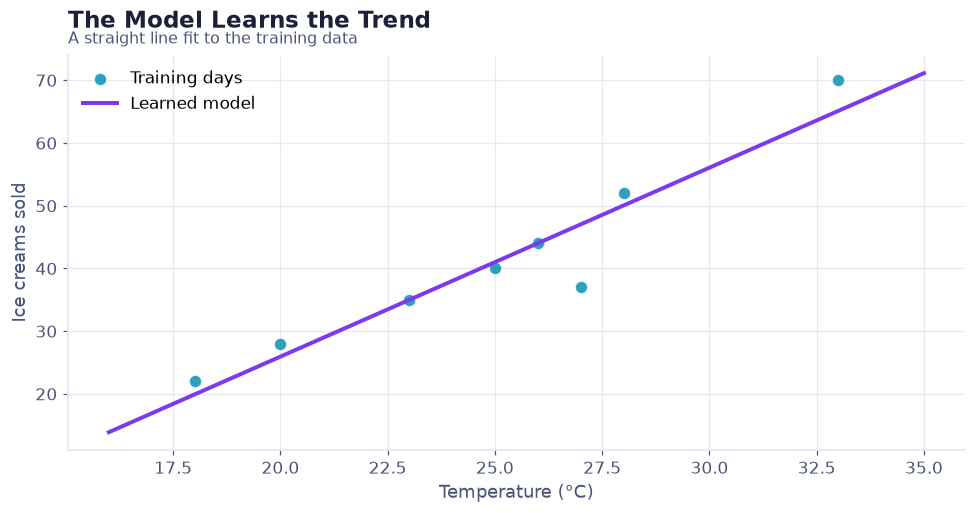

In [8]:
fig, ax = plt.subplots(figsize=(9,4.8))
ax.scatter(train["temperature"], train["sales"], color=CYAN, s=70, alpha=0.85, edgecolor="white", label="Training days")
xs = np.linspace(16, 35, 100)
ax.plot(xs, slope*xs+intercept, color=PURPLE, lw=2.6, label="Learned model")
titlecard(ax, "The Model Learns the Trend", "A straight line fit to the training data")
ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("Ice creams sold"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

<div style="background:#fce7f3;border-left:5px solid #db2777;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#db2777;letter-spacing:1px">STAGE 6 · EVALUATE &amp; DEPLOY</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">✅ Test it, then put it to work</div>
<div style="color:#4a5578;margin-top:6px">Input: the trained model + held-out test data. Output: an honest score and a usable forecast tool.</div>
</div>

In [9]:
# Evaluate on the TEST days the model never saw
pred_test = slope*test["temperature"] + intercept
rmse = np.sqrt(np.mean((test["sales"].values - pred_test.values)**2))
ss_res = np.sum((test["sales"].values - pred_test.values)**2)
ss_tot = np.sum((test["sales"].values - test["sales"].mean())**2)
r2 = 1 - ss_res/ss_tot
print(f"On unseen test days:  RMSE = {rmse:.1f} ice creams,   R² = {r2:.2f}")

# DEPLOY = wrap the model in a simple tool anyone can use
def predict_sales(temp_c):
    return max(0, round(slope*temp_c + intercept))

tomorrow = 29
print(f"\n📦 Forecast: tomorrow is {tomorrow}°C -> stock for about {predict_sales(tomorrow)} ice creams.")

On unseen test days:  RMSE = 4.1 ice creams,   R² = 0.90

📦 Forecast: tomorrow is 29°C -> stock for about 53 ice creams.


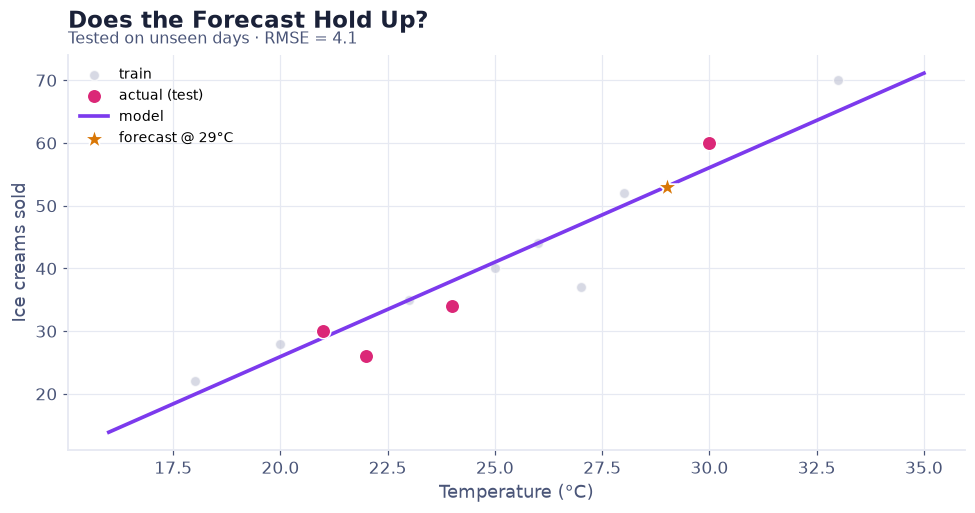

In [10]:
# Communicate: show predictions vs. reality on the test days
fig, ax = plt.subplots(figsize=(9,4.8))
ax.scatter(train["temperature"], train["sales"], color="#c7c9d9", s=45, alpha=0.7, edgecolor="white", label="train")
ax.scatter(test["temperature"], test["sales"], color=PINK, s=90, edgecolor="white", linewidth=1, zorder=5, label="actual (test)")
ax.plot(xs, slope*xs+intercept, color=PURPLE, lw=2.4, label="model")
ax.scatter([tomorrow],[predict_sales(tomorrow)], color=AMBER, s=200, marker="*", zorder=6, edgecolor="white", linewidth=1.2, label=f"forecast @ {tomorrow}°C")
titlecard(ax, "Does the Forecast Hold Up?", f"Tested on unseen days · RMSE = {rmse:.1f}")
ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("Ice creams sold"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

And in production you'd **monitor** it: if a heatwave or a new flavor shifts behavior, the errors grow, a signal to loop back to Stage 2 with fresh data. The lifecycle is a **circle**, not a line.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap, one project, six stages</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Frame</b> → a measurable question (predict sales from temperature, judged by RMSE).</li>
<li><b>Collect</b> → a raw, messy 14-day dataset.</li>
<li><b>Clean</b> → removed a duplicate, filled a missing value, dropped an outlier.</li>
<li><b>Explore</b> → found a strong positive correlation (≈ 0.98).</li>
<li><b>Model</b> → fit a line on the training days only.</li>
<li><b>Evaluate &amp; Deploy</b> → scored it on unseen days, then shipped a <code>predict_sales()</code> tool.</li>
</ul>
<div style="margin-top:12px;padding-top:12px;border-top:1px dashed #e6e9f2;color:#7c3aed;font-weight:700">Every real data-science project, from Netflix to fraud detection, follows this same loop.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>